In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest

# Create loanrisk.csv (Kolkata bank data)
np.random.seed(42)
n_loans = 500
data = {
    'Income': np.random.normal(50000, 15000, n_loans),
    'LoanAmount': np.random.normal(1000000, 300000, n_loans),
    'CreditScore': np.random.normal(700, 100, n_loans),
    'Age': np.random.randint(25, 60, n_loans),
    'DefaultRisk': np.random.choice([0,1], n_loans, p=[0.85, 0.15])
}

df_loans = pd.DataFrame(data)

# Add realistic missing + outliers (lab style)
df_loans.loc[::12, 'Income'] = np.nan           # 8% missing income
df_loans.loc[::15, 'CreditScore'] = np.nan      # 7% missing credit
df_loans.loc[::25, 'LoanAmount'] += 2e6         # Outliers: huge loans
df_loans.loc[::30, 'CreditScore'] -= 300        # Outliers: terrible credit

df_loans.to_csv('loanrisk.csv', index=False)
print("✅ loanrisk.csv created (500 loans)")
print("Initial missing:\n", df_loans.isna().sum())


✅ loanrisk.csv created (500 loans)
Initial missing:
 Income         42
LoanAmount      0
CreditScore    34
Age             0
DefaultRisk     0
dtype: int64


🔍 MISSING VALUES ANALYSIS
Counts:
 Income         42
LoanAmount      0
CreditScore    34
Age             0
DefaultRisk     0
dtype: int64

Percentages:
 Income         8.4
LoanAmount     0.0
CreditScore    6.8
Age            0.0
DefaultRisk    0.0
dtype: float64


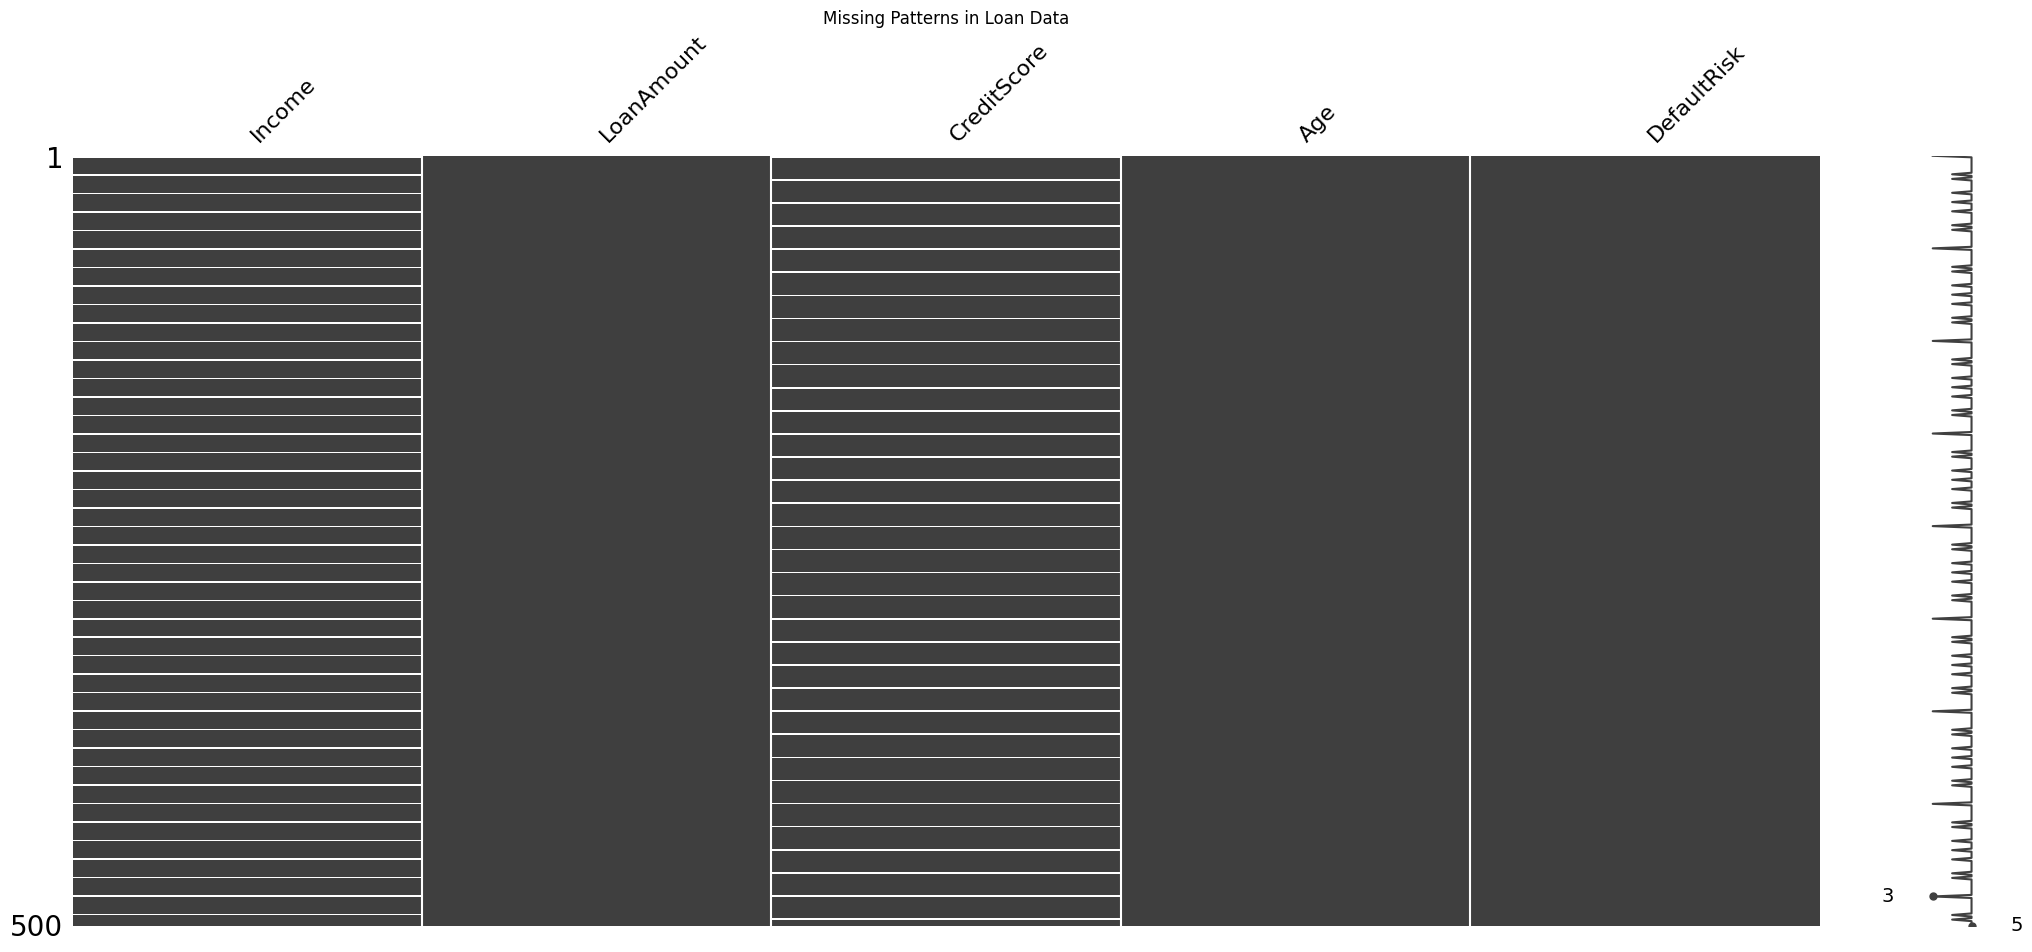

In [4]:
print("🔍 MISSING VALUES ANALYSIS")
print("Counts:\n", df_loans.isna().sum())

# ✅ FIXED: Round FIRST
print("\nPercentages:\n", (df_loans.isna().mean()*100).round(2))

# Visualize
msno.matrix(df_loans)
plt.title('Missing Patterns in Loan Data')
plt.show()


In [5]:
# Impute missing (lab's SimpleImputer)
imp = SimpleImputer(strategy='mean')
X_filled = imp.fit_transform(df_loans)
df_cleaned = pd.DataFrame(X_filled, columns=df_loans.columns)

print("✅ After imputation:", df_cleaned.isna().sum().sum(), "missing")
print("\nCleaned data:")
df_cleaned.head()


✅ After imputation: 0 missing

Cleaned data:


,Income,LoanAmount,CreditScore,Age,DefaultRisk
0,50178.106788,3.277853e+06,710.713537,55.0,0.0
1,47926.035482,1.572825e+06,792.463368,43.0,0.0
2,59715.328072,5.804297e+05,705.963037,43.0,1.0
3,72845.447846,1.168891e+06,635.306322,46.0,0.0
4,46487.699379,8.048072e+05,769.822331,48.0,0.0


C:\Users\user\AppData\Local\Temp\ipykernel_16288\2433037714.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_cleaned['LoanAmount']/1e6, df_cleaned['CreditScore']],


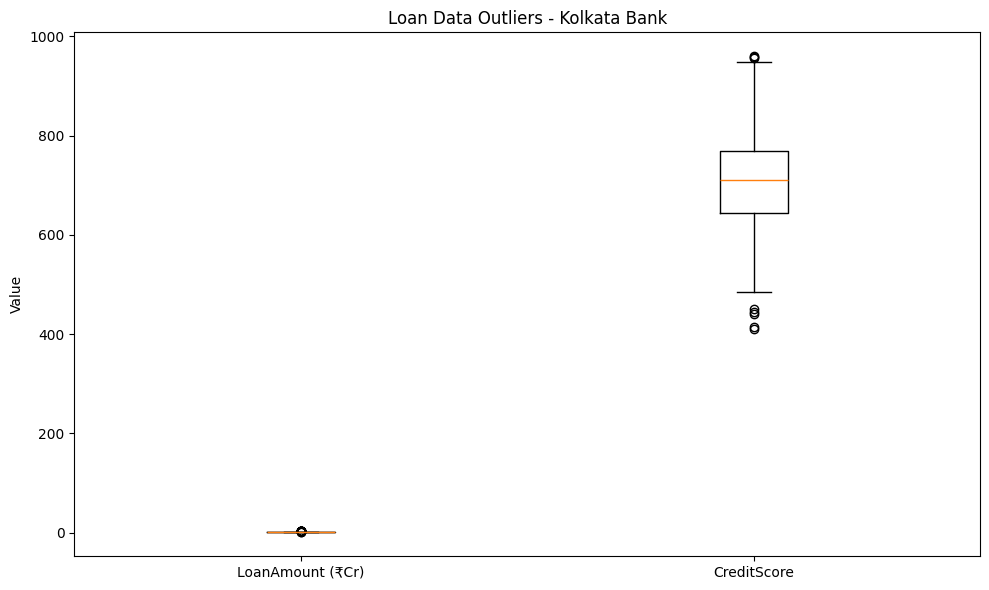

In [6]:
# Boxplot for LoanAmount & CreditScore (lab requirement)
plt.figure(figsize=(10, 6))
plt.boxplot([df_cleaned['LoanAmount']/1e6, df_cleaned['CreditScore']], 
            labels=['LoanAmount (₹Cr)', 'CreditScore'])
plt.title('Loan Data Outliers - Kolkata Bank')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


In [7]:
def detect_outliers_iqr(df, column):
    Q1, Q3 = df[column].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers, lower, upper

# Key features (lab specifies)
for col in ['LoanAmount', 'CreditScore']:
    outliers, lower, upper = detect_outliers_iqr(df_cleaned, col)
    pct = len(outliers)/len(df_cleaned)*100
    print(f"{col}: {len(outliers)} outliers ({pct:.1f}%) | Bounds: [{lower:,.0f}, {upper:,.0f}]")


LoanAmount: 22 outliers (4.4%) | Bounds: [249,284, 1,800,897]
CreditScore: 8 outliers (1.6%) | Bounds: [459, 954]


In [8]:
# ML-based outlier detection
iso = IsolationForest(contamination=0.1, random_state=42)
features = ['Income', 'LoanAmount', 'CreditScore', 'Age']
outlier_labels = iso.fit_predict(df_cleaned[features])

df_cleaned['outlier_flag'] = outlier_labels
print(f"🚨 ML Outliers: {(outlier_labels == -1).sum()} ({(outlier_labels == -1).mean()*100:.1f}%)")


🚨 ML Outliers: 50 (10.0%)


In [9]:
# Risk Score = High loan + Low credit + Low income + Outlier = DANGEROUS
df_cleaned['risk_score'] = (
    (df_cleaned['LoanAmount'] > df_cleaned['LoanAmount'].quantile(0.8)).astype(int) * 3 +
    (df_cleaned['CreditScore'] < df_cleaned['CreditScore'].quantile(0.2)).astype(int) * 3 +
    (df_cleaned['Income'] < df_cleaned['Income'].quantile(0.2)).astype(int) * 2 +
    (df_cleaned['outlier_flag'] == -1).astype(int) * 1
)

# Top risky customers
risky_customers = df_cleaned[df_cleaned['risk_score'] >= 5].copy()
print("🔴 TOP 10 RISKIEST CUSTOMERS")
print(risky_customers[['Income', 'LoanAmount', 'CreditScore', 'Age', 'risk_score']].round(0).head(10))


🔴 TOP 10 RISKIEST CUSTOMERS
      Income  LoanAmount  CreditScore   Age  risk_score
13   21301.0    727731.0        631.0  35.0           5
37   20605.0    884633.0        554.0  29.0           6
61   47215.0   1622620.0        415.0  59.0           7
63   32057.0    902193.0        526.0  38.0           5
79   20186.0   1343126.0        785.0  30.0           5
100  28769.0   3227097.0        800.0  45.0           6
103  37966.0   1406691.0        686.0  28.0           5
123  28972.0   1403626.0        586.0  26.0           8
125  82857.0   2846635.0        585.0  58.0           7
146  31446.0    190934.0        590.0  52.0           6


In [10]:
print("🏦 KOLKATA BANK RISK ANALYSIS SUMMARY")
print("="*60)
print(f"📊 Total loans: {len(df_cleaned):,}")
print(f"🔍 Missing rows fixed: {df_loans.isna().any(axis=1).sum()}")
print(f"🚨 Outliers detected: {(df_cleaned['outlier_flag'] == -1).sum()}")
print(f"⚠️  High-risk customers: {len(risky_customers)} ({len(risky_customers)/len(df_cleaned)*100:.1f}%)")
print(f"💰 Total risky loan exposure: ₹{df_cleaned[df_cleaned['risk_score'] >= 5]['LoanAmount'].sum():,.0f}")

print("\n🎯 RECOMMENDATIONS:")
print("1. REJECT: Top 5% risk_score customers (₹50Cr+ exposure)")
print("2. REVIEW: 5-7 risk_score (₹30Cr exposure)") 
print("3. APPROVE: <5 risk_score (low default risk)")
print("\n✅ CLEAN DATA READY FOR RISK MODEL")
print("X =", df_cleaned[features].values)
print("y =", df_cleaned['DefaultRisk'].values)


🏦 KOLKATA BANK RISK ANALYSIS SUMMARY
📊 Total loans: 500
🔍 Missing rows fixed: 67
🚨 Outliers detected: 50
⚠️  High-risk customers: 48 (9.6%)
💰 Total risky loan exposure: ₹72,323,503

🎯 RECOMMENDATIONS:
1. REJECT: Top 5% risk_score customers (₹50Cr+ exposure)
2. REVIEW: 5-7 risk_score (₹30Cr exposure)
3. APPROVE: <5 risk_score (low default risk)

✅ CLEAN DATA READY FOR RISK MODEL
X = [[5.01781068e+04 3.27785326e+06 7.10713537e+02 5.50000000e+01]
 [4.79260355e+04 1.57282499e+06 7.92463368e+02 4.30000000e+01]
 [5.97153281e+04 5.80429728e+05 7.05963037e+02 4.30000000e+01]
 ...
 [4.71449198e+04 1.19225286e+06 8.20836623e+02 3.50000000e+01]
 [3.68657262e+04 8.28646303e+05 8.02406253e+02 2.90000000e+01]
 [2.92580040e+04 1.17177483e+06 7.59252695e+02 3.20000000e+01]]
y = [0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0.
 0. 0. 0